
# Recruitment Regression Template

This notebook is a **template** for running the pair-specific Illinois-vs-control regression for the **Recruitment** analytic sample.

## What this notebook assumes

- You are running a regression for **one adjacent year pair at a time**
- Each row in the file already represents a **transition from year t to year t+1**
- The dependent variable is already constructed in the analytic sample:
  - `joined_state_local`
- The key treatment indicator is:
  - `illinois` = 1 for Illinois, 0 for control states

## Interpretation

Because the file is already constructed at the transition level, this notebook estimates a **cross-sectional regression on a transition outcome** for a single year pair. This is your **pair-specific DiD-style regression** for the Recruitment margin.


In [31]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

# -------------------------------------------------------------------
# CONFIGURATION
# -------------------------------------------------------------------
PROJECT_DIR = Path("/Users/subhronil/pdi/pdi_pensions-1/regression_analysis")
DATA_DIR = Path("/Users/subhronil/pdi/pdi_pensions-1/regression_analysis")

if not DATA_DIR.exists():
    alt = PROJECT_DIR / "data" / "analytic samples" / "recruitment"
    if alt.exists():
        DATA_DIR = alt

OUTPUT_DIR = Path.home() / "Downloads"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

YEAR_PAIRS = [
    (2008, 2009),
    (2009, 2010),
    (2010, 2011),
    (2011, 2012),
    (2012, 2013),
    (2013, 2014),
    (2014, 2015),
    (2015, 2016),
    (2016, 2017)
]

FILE_PATTERN = "analytic_sample_{yy0}{yy1}_recruitment.csv"

DV             = "joined_state_local"
TREATMENT_VAR  = "illinois"
PAIR_VAR       = "pair"

WEIGHT_CANDIDATES = [
    "weight_t", "wgt_t", "wtfinl_t", "finalwgt_t",
    "weight", "wgt", "wtfinl", "finalwgt",
    "earnwt_t", "earnwt"
]

COV_TYPE = "HC1"

# FIPS codes: NY=36, Indiana=18, PA=42
STATE_FILTER_COMBOS = {
    "all_states": [],
    "no_ny":      [36],
    "no_indiana": [18],
    "no_pa":      [42],
    "no_ny_pa":   [36, 42],
    "no_ny_in":   [36, 18],
    "no_in_pa":   [18, 42],
}

print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists?", DATA_DIR.exists())
if DATA_DIR.exists():
    print("CSV files found:", [p.name for p in sorted(DATA_DIR.glob("*.csv"))])


DATA_DIR: /Users/subhronil/pdi/pdi_pensions-1/regression_analysis
DATA_DIR exists? True
CSV files found: ['08-13_combined.csv', 'all_results_combined.csv', 'all_state_combinations_combined.csv', 'analytic_sample_0809_recruitment.csv', 'analytic_sample_0809_retention.csv', 'analytic_sample_0910_recruitment.csv', 'analytic_sample_0910_retention.csv', 'analytic_sample_1011_recruitment.csv', 'analytic_sample_1011_retention.csv', 'analytic_sample_1112_recruitment.csv', 'analytic_sample_1112_retention.csv', 'analytic_sample_1213_recruitment.csv', 'analytic_sample_1213_retention.csv', 'analytic_sample_1314_recruitment.csv', 'analytic_sample_1314_retention.csv', 'analytic_sample_1415_recruitment.csv', 'analytic_sample_1415_retention.csv', 'analytic_sample_1516_recruitment.csv', 'analytic_sample_1617_recruitment.csv', 'result_0809_no_ny.csv']


In [32]:

# -------------------------------------------------------------------
# CONTROL VARIABLES
# -------------------------------------------------------------------
CONTINUOUS_CONTROL_CANDIDATES = [
    "age_t",
    "I(age_t**2)",
    "np.log(earnwke_t)",
]

CATEGORICAL_CONTROL_CANDIDATES = [
    "C(sex_t)",
    "C(race_t)",
    "C(ethnic_t)",
    "C(ethnicity_t)",
    "C(hispan_t)",
    "C(hispanic_t)",
    "C(hisp_t)",
    "C(grade92_t)",
    "C(educ_t)",
    "C(docc00_t)",
    "C(docc80_t)",
    "C(occ2010_t)",
    "C(occ_t)",
    "C(ind02_t)",
    "C(naics2_t)",
    "C(ind_t)",
    "C(unionmme_t)",
    "C(unioncov_t)",
]

ALL_CONTROL_CANDIDATES = CONTINUOUS_CONTROL_CANDIDATES + CATEGORICAL_CONTROL_CANDIDATES


def extract_needed_columns(terms):
    cols = set()
    for term in terms:
        for m in re.findall(r"C\(([^)]+)\)", term):
            cols.add(m.strip())
        for m in re.findall(r"np\.log\(([^)]+)\)", term):
            cols.add(m.strip())
        for expr in re.findall(r"I\(([^)]+)\)", term):
            for v in re.findall(r"[A-Za-z_][A-Za-z0-9_]*", expr):
                if v not in {"I", "C", "np", "log"}:
                    cols.add(v)
        if not term.startswith(("C(", "I(", "np.log(")):
            for v in re.findall(r"[A-Za-z_][A-Za-z0-9_]*", term):
                if v not in {"I", "C", "np", "log"}:
                    cols.add(v)
    return sorted(cols)


def is_categorical_term(term):
    return term.startswith("C(")


def categorical_column_from_term(term):
    m = re.match(r"C\(([^)]+)\)", term)
    return m.group(1).strip() if m else None


def choose_one_present(terms, priority):
    present = [t for t in priority if t in terms]
    if len(present) <= 1:
        return terms
    keep = present[0]
    return [t for t in terms if (t not in priority or t == keep)]


def available_terms(df, candidate_terms):
    terms = []
    for term in candidate_terms:
        raw_cols = extract_needed_columns([term])
        if all(c in df.columns for c in raw_cols):
            terms.append(term)
    terms = choose_one_present(terms, ["C(docc00_t)", "C(docc80_t)", "C(occ2010_t)", "C(occ_t)"])
    terms = choose_one_present(terms, ["C(ind02_t)", "C(naics2_t)", "C(ind_t)"])
    terms = choose_one_present(terms, ["C(hispan_t)", "C(hispanic_t)", "C(hisp_t)", "C(ethnic_t)", "C(ethnicity_t)"])
    return terms


def build_formula(dv, controls):
    return f"{dv} ~ " + " + ".join([TREATMENT_VAR] + controls)


def detect_weight_var(df):
    for c in WEIGHT_CANDIDATES:
        if c in df.columns:
            return c
    return None


# -------------------------------------------------------------------
# STATE COLUMN DETECTION
# stfips_t for files before 2013, stfips for 2013 onwards
# -------------------------------------------------------------------
def get_state_col(df):
    if "stfips_t" in df.columns:
        return "stfips_t"
    elif "stfips" in df.columns:
        return "stfips"
    else:
        return None


# -------------------------------------------------------------------
# FILE LOADING + STATE FILTERING
# -------------------------------------------------------------------
def pair_to_file(y0, y1):
    yy0 = str(y0)[-2:]
    yy1 = str(y1)[-2:]
    return DATA_DIR / FILE_PATTERN.format(yy0=yy0, yy1=yy1)


def load_pair(y0, y1):
    path = pair_to_file(y0, y1)
    print("\n" + "=" * 80)
    print(f"PAIR {y0}-{y1}  |  Looking for: {path.name}")

    if not path.exists():
        print(f"WARNING: file not found, skipping.")
        return None

    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.lower().str.strip()
    df[PAIR_VAR] = f"{str(y0)[-2:]}{str(y1)[-2:]}"

    state_col = get_state_col(df)
    print(f"Loaded shape: {df.shape} | State column: {state_col} | Weight: {detect_weight_var(df)}")
    return df


def remove_states(df, fips_list):
    if not fips_list:
        return df.copy()

    state_col = get_state_col(df)
    if state_col is None:
        print("  WARNING: no state column found, skipping filter")
        return df.copy()

    before = len(df)
    vals = pd.to_numeric(df[state_col], errors="coerce")
    mask = vals.isin(fips_list)
    df2 = df.loc[~mask].copy()
    print(f"  Removed {before - len(df2):,} rows matching FIPS {fips_list} using '{state_col}'")
    return df2


# -------------------------------------------------------------------
# DATA CLEANING
# -------------------------------------------------------------------
def clean_categorical_series(s):
    out = s.astype("object")
    out = out.where(~pd.isna(out), "MISSING")
    out = out.astype(str).str.strip()
    out = out.replace({
        "": "MISSING", "<NA>": "MISSING", "nan": "MISSING",
        "NaN": "MISSING", "None": "MISSING", "none": "MISSING",
    })
    return out.astype("object")


def prepare_model_data(df, controls):
    weight_var = detect_weight_var(df)
    if weight_var is None:
        return None, None, "No weight variable found"

    missing = [c for c in [DV, TREATMENT_VAR] if c not in df.columns]
    if missing:
        return None, None, f"Missing required columns: {missing}"

    data = df.copy()
    data[weight_var]      = pd.to_numeric(data[weight_var], errors="coerce")
    data[DV]              = pd.to_numeric(data[DV], errors="coerce")
    data[TREATMENT_VAR]   = pd.to_numeric(data[TREATMENT_VAR], errors="coerce")

    numeric_cols = [DV, TREATMENT_VAR, weight_var]
    for term in controls:
        if not is_categorical_term(term):
            numeric_cols.extend(extract_needed_columns([term]))
    numeric_cols = sorted(set(c for c in numeric_cols if c in data.columns))

    for c in numeric_cols:
        data[c] = pd.to_numeric(data[c], errors="coerce")

    for term in controls:
        if is_categorical_term(term):
            c = categorical_column_from_term(term)
            if c and c in data.columns:
                data[c] = clean_categorical_series(data[c])

    if "np.log(earnwke_t)" in controls and "earnwke_t" in data.columns:
        data = data[data["earnwke_t"] > 0].copy()

    before = len(data)
    data = data.dropna(subset=numeric_cols).copy()
    data = data[data[weight_var] > 0].copy()

    if data.empty:
        return None, weight_var, "No rows left after cleaning"

    return data, weight_var, None



In [33]:

# -------------------------------------------------------------------
# REGRESSION
# -------------------------------------------------------------------
def run_weighted_lpm(df, y0, y1, sample_name):
    controls   = available_terms(df, ALL_CONTROL_CANDIDATES)
    data, weight_var, error = prepare_model_data(df, controls)

    if error:
        print(f"  Skipping {y0}-{y1} / {sample_name}: {error}")
        return None

    formula = build_formula(DV, controls)

    try:
        result = smf.wls(
            formula=formula,
            data=data,
            weights=data[weight_var]
        ).fit(cov_type=COV_TYPE)
    except Exception as e:
        print(f"  Regression failed {y0}-{y1} / {sample_name}: {e}")
        return None

    coef    = result.params.get(TREATMENT_VAR, np.nan)
    se      = result.bse.get(TREATMENT_VAR, np.nan)
    pval    = result.pvalues.get(TREATMENT_VAR, np.nan)
    z       = result.tvalues.get(TREATMENT_VAR, np.nan)
    ci      = result.conf_int()
    ci_low  = ci.loc[TREATMENT_VAR, 0] if TREATMENT_VAR in ci.index else np.nan
    ci_high = ci.loc[TREATMENT_VAR, 1] if TREATMENT_VAR in ci.index else np.nan

    print(f"  {sample_name}: coef={coef:.4f}, se={se:.4f}, p={pval:.3f}, n={int(result.nobs)}")

    return {
        "pair":               f"{y0}-{y1}",
        "pair_code":          f"{str(y0)[-2:]}{str(y1)[-2:]}",
        "sample":             sample_name,
        "coef":               coef,
        "coef_pct_points":    coef * 100 if pd.notna(coef) else np.nan,
        "std_err":            se,
        "z_score":            z,
        "p_value":            pval,
        "ci_low_pct_points":  ci_low  * 100 if pd.notna(ci_low)  else np.nan,
        "ci_high_pct_points": ci_high * 100 if pd.notna(ci_high) else np.nan,
        "nobs":               int(result.nobs),
        "r_squared":          result.rsquared,
        "weight_var":         weight_var,
        "formula":            formula,
    }


# -------------------------------------------------------------------
# MAIN LOOP
# -------------------------------------------------------------------
all_results = []

for y0, y1 in YEAR_PAIRS:
    df_raw = load_pair(y0, y1)
    if df_raw is None:
        continue

    for sample_name, fips_list in STATE_FILTER_COMBOS.items():
        df_filtered = remove_states(df_raw, fips_list)
        row = run_lpm(df_filtered, y0, y1, sample_name)
        if row:
            all_results.append(row)

combined = pd.DataFrame(all_results)

print("\n" + "=" * 80)
print(f"DONE — {len(combined)} total rows")
display(combined)

# -------------------------------------------------------------------
# SAVE
# -------------------------------------------------------------------
out_csv  = OUTPUT_DIR / "recruitment_illinois_effects_by_sample.csv"
out_xlsx = OUTPUT_DIR / "recruitment_illinois_effects_by_sample.xlsx"

combined.to_csv(out_csv, index=False)

with pd.ExcelWriter(out_xlsx) as writer:
    combined.to_excel(writer, sheet_name="all_results", index=False)
    for sample_name in STATE_FILTER_COMBOS.keys():
        subset = combined[combined["sample"] == sample_name].reset_index(drop=True)
        subset.to_excel(writer, sheet_name=sample_name[:31], index=False)

print(f"Saved to: {out_csv}")
print(f"Saved to: {out_xlsx}")


PAIR 2008-2009  |  Looking for: analytic_sample_0809_recruitment.csv
Loaded shape: (18302, 205) | State column: stfips_t | Weight: weight_t
  all_states: coef=-0.0016, se=0.0047, p=0.738, n=9369
  Removed 6,172 rows matching FIPS [36] using 'stfips_t'
  no_ny: coef=0.0012, se=0.0053, p=0.826, n=6424
  Removed 2,427 rows matching FIPS [18] using 'stfips_t'
  no_indiana: coef=0.0001, se=0.0049, p=0.976, n=8053
  Removed 5,063 rows matching FIPS [42] using 'stfips_t'
  no_pa: coef=-0.0057, se=0.0053, p=0.282, n=6667
  Removed 11,235 rows matching FIPS [36, 42] using 'stfips_t'
  no_ny_pa: coef=-0.0089, se=0.0075, p=0.237, n=3722
  Removed 8,599 rows matching FIPS [36, 18] using 'stfips_t'
  no_ny_in: coef=0.0054, se=0.0057, p=0.339, n=5108
  Removed 7,490 rows matching FIPS [18, 42] using 'stfips_t'
  no_in_pa: coef=-0.0049, se=0.0059, p=0.401, n=5351

PAIR 2009-2010  |  Looking for: analytic_sample_0910_recruitment.csv
Loaded shape: (18724, 203) | State column: stfips_t | Weight: weight

,pair,pair_code,sample,coef,coef_pct_points,std_err,z_score,p_value,ci_low_pct_points,ci_high_pct_points,nobs,r_squared,weight_var,formula
0,2008-2009,0809,all_states,-0.001584,-0.158429,0.004745,-0.333904,0.738452,-1.088379,0.771522,9369,0.063301,weight_t,joined_state_local ~ illinois + age_t + I(age_...
1,2008-2009,0809,no_ny,0.001154,0.115402,0.005251,0.219774,0.826047,-0.913763,1.144566,6424,0.068868,weight_t,joined_state_local ~ illinois + age_t + I(age_...
2,2008-2009,0809,no_indiana,0.000145,0.014526,0.004913,0.029565,0.976414,-0.948470,0.977523,8053,0.066967,weight_t,joined_state_local ~ illinois + age_t + I(age_...
3,2008-2009,0809,no_pa,-0.005671,-0.567106,0.005268,-1.076476,0.281714,-1.599648,0.465436,6667,0.081837,weight_t,joined_state_local ~ illinois + age_t + I(age_...
4,2008-2009,0809,no_ny_pa,-0.008913,-0.891291,0.007544,-1.181423,0.237435,-2.369932,0.587349,3722,0.110820,weight_t,joined_state_local ~ illinois + age_t + I(age_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,2016-2017,1617,no_indiana,0.000633,0.063315,0.004988,0.126942,0.898986,-0.914251,1.040881,5596,0.106236,weight_t,joined_state_local ~ illinois + age_t + I(age_...
59,2016-2017,1617,no_pa,-0.001923,-0.192282,0.005226,-0.367954,0.712908,-1.216501,0.831938,4796,0.101589,weight_t,joined_state_local ~ illinois + age_t + I(age_...
60,2016-2017,1617,no_ny_pa,-0.001539,-0.153904,0.007211,-0.213433,0.830989,-1.567211,1.259403,2626,0.171349,weight_t,joined_state_local ~ illinois + age_t + I(age_...
61,2016-2017,1617,no_ny_in,0.000744,0.074365,0.006121,0.121490,0.903303,-1.125343,1.274072,3426,0.158607,weight_t,joined_state_local ~ illinois + age_t + I(age_...


Saved to: /Users/subhronil/Downloads/recruitment_illinois_effects_by_sample.csv
Saved to: /Users/subhronil/Downloads/recruitment_illinois_effects_by_sample.xlsx


In [34]:
import os

# All your data files
data_files = {
    "08-09": "/Users/subhronil/pdi/pdi_pensions-1/regression_analysis/analytic_sample_0809_recruitment.csv",
    "09-10": "/Users/subhronil/pdi/pdi_pensions-1/regression_analysis/analytic_sample_0910_recruitment.csv",
    "10-11": "/Users/subhronil/pdi/pdi_pensions-1/regression_analysis/analytic_sample_1011_recruitment.csv",
    "11-12": "/Users/subhronil/pdi/pdi_pensions-1/regression_analysis/analytic_sample_1112_recruitment.csv",
    "12-13": "/Users/subhronil/pdi/pdi_pensions-1/regression_analysis/analytic_sample_1213_recruitment.csv",
    "13-14": "/Users/subhronil/pdi/pdi_pensions-1/regression_analysis/analytic_sample_1314_recruitment.csv",
    "14-15": "/Users/subhronil/pdi/pdi_pensions-1/regression_analysis/analytic_sample_1415_recruitment.csv",
    "15-16": "/Users/subhronil/pdi/pdi_pensions-1/regression_analysis/analytic_sample_1516_recruitment.csv",
    "16-17": "/Users/subhronil/pdi/pdi_pensions-1/regression_analysis/analytic_sample_1617_recruitment.csv",
}
def drop_states(df, fips_list):
    if not fips_list:
        return df.copy()
    
    # Use stfips_t for pre-2013 files, stfips for post-2013
    if "stfips_t" in df.columns:
        state_col = "stfips_t"
    elif "stfips" in df.columns:
        state_col = "stfips"
    else:
        raise ValueError(f"No state FIPS column found. Available: {df.columns.tolist()}")
    
    mask = pd.Series([True] * len(df), index=df.index)
    for fips in fips_list:
        mask = mask & (df[state_col] != fips)
    return df[mask].copy()

NY = 36
IN = 18
PA = 42

state_filters = {
    "all_states": [],
    "no_ny":      [NY],
    "no_indiana": [IN],
    "no_pa":      [PA],
    "no_ny_pa":   [NY, PA],
    "no_ny_in":   [NY, IN],
    "no_in_pa":   [IN, PA],
}

all_results = []

for pair, filepath in data_files.items():
    print(f"\n--- Year pair: {pair} ---")
    
    if not os.path.exists(filepath):
        print(f"  FILE NOT FOUND: {filepath}")
        continue
    
    y0, y1 = int("20" + pair[:2]), int("20" + pair[3:])
    df_raw = pd.read_csv(filepath, low_memory=False)
    df_raw.columns = df_raw.columns.str.lower().str.strip()
    
    for filter_name, fips_list in state_filters.items():
        df_filtered = drop_states(df_raw, fips_list)
        print(f"  {filter_name}: {len(df_filtered)} rows")
        
        row = run_weighted_lpm(df_filtered, y0, y1, filter_name)
        if row:
            all_results.append(row)

combined = pd.DataFrame(all_results)
# Save to current working directory
save_path = os.path.join(os.getcwd(), "all_state_combinations_combined.csv")
combined.to_csv(save_path, index=False)
print(f"\nSaved to: {save_path}")
print("\n", combined)



--- Year pair: 08-09 ---
  all_states: 18302 rows
  all_states: coef=-0.0016, se=0.0047, p=0.738, n=9369
  no_ny: 12130 rows
  no_ny: coef=0.0012, se=0.0053, p=0.826, n=6424
  no_indiana: 15875 rows
  no_indiana: coef=0.0001, se=0.0049, p=0.976, n=8053
  no_pa: 13239 rows
  no_pa: coef=-0.0057, se=0.0053, p=0.282, n=6667
  no_ny_pa: 7067 rows
  no_ny_pa: coef=-0.0089, se=0.0075, p=0.237, n=3722
  no_ny_in: 9703 rows
  no_ny_in: coef=0.0054, se=0.0057, p=0.339, n=5108
  no_in_pa: 10812 rows
  no_in_pa: coef=-0.0049, se=0.0059, p=0.401, n=5351

--- Year pair: 09-10 ---
  all_states: 18724 rows
  all_states: coef=0.0020, se=0.0046, p=0.664, n=9110
  no_ny: 12467 rows
  no_ny: coef=0.0084, se=0.0050, p=0.093, n=6157
  no_indiana: 16139 rows
  no_indiana: coef=0.0014, se=0.0048, p=0.770, n=7887
  no_pa: 13609 rows
  no_pa: coef=-0.0046, se=0.0051, p=0.369, n=6620
  no_ny_pa: 7352 rows
  no_ny_pa: coef=-0.0024, se=0.0075, p=0.748, n=3667
  no_ny_in: 9882 rows
  no_ny_in: coef=0.0118, se=0.0

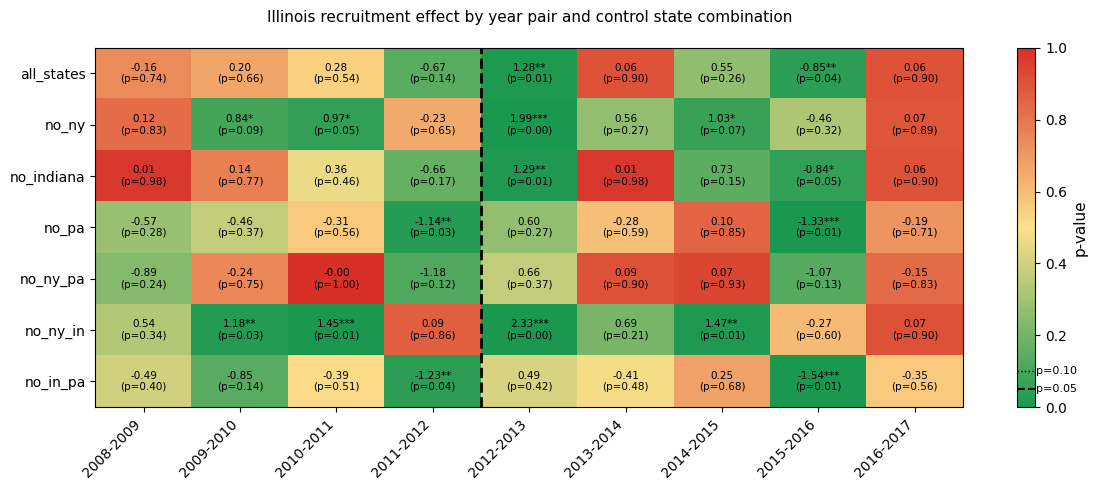

Saved to Downloads


In [36]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# Load your results
combined = pd.read_csv("/Users/subhronil/Downloads/recruitment_illinois_effects_by_sample.csv")

# Pivot to get p-values as a matrix
pivot = combined.pivot(index="sample", columns="pair", values="p_value")

# Order year pairs chronologically
pair_order = ["2008-2009", "2009-2010", "2010-2011", "2011-2012", "2012-2013", "2013-2014", "2014-2015", "2015-2016", "2016-2017"]
sample_order = ["all_states", "no_ny", "no_indiana", "no_pa", "no_ny_pa", "no_ny_in", "no_in_pa"]

pivot = pivot.reindex(index=sample_order, columns=pair_order)

# Also get coefficients for annotation
pivot_coef = combined.pivot(index="sample", columns="pair", values="coef_pct_points")
pivot_coef = pivot_coef.reindex(index=sample_order, columns=pair_order)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))

# Custom colormap: green (insignificant) -> red (significant)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "pval_cmap", ["#d73027", "#fee08b", "#1a9850"], N=256
)
# Reverse so red = low p-value (significant)
cmap = cmap.reversed()

im = ax.imshow(pivot.values.astype(float), cmap=cmap, vmin=0, vmax=1, aspect="auto")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("p-value", fontsize=11)
cbar.ax.axhline(y=0.05, color="black", linewidth=1.5, linestyle="--")
cbar.ax.axhline(y=0.10, color="black", linewidth=1, linestyle=":")
cbar.ax.text(1.05, 0.05, "p=0.05", transform=cbar.ax.transAxes,
             va="center", fontsize=8)
cbar.ax.text(1.05, 0.10, "p=0.10", transform=cbar.ax.transAxes,
             va="center", fontsize=8)

# Annotate each cell with coefficient and p-value
for i in range(len(sample_order)):
    for j in range(len(pair_order)):
        coef = pivot_coef.values[i, j]
        pval = pivot.values[i, j]
        if not np.isnan(coef) and not np.isnan(pval):
            sig = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""
            ax.text(j, i,
                    f"{coef:.2f}{sig}\n(p={pval:.2f})",
                    ha="center", va="center", fontsize=7.5,
                    color="black")

# Axis labels
ax.set_xticks(range(len(pair_order)))
ax.set_xticklabels(pair_order, rotation=45, ha="right", fontsize=10)
ax.set_yticks(range(len(sample_order)))
ax.set_yticklabels(sample_order, fontsize=10)

# Reform line between 2011-2012 and 2012-2013 (between columns 3 and 4)
ax.axvline(x=3.5, color="black", linewidth=2, linestyle="--")

ax.set_title("Illinois recruitment effect by year pair and control state combination\n",
             fontsize=11)

plt.tight_layout()
plt.savefig("/Users/subhronil/Downloads/recruitment_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to Downloads")